In [2]:
from google.colab import files
u=files.upload()

Saving ipl_dataset.csv to ipl_dataset.csv


In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('ipl_dataset.csv')
df.head()

,full_scorecard,team1,team2,team1_score,team2_score,toss_winner,toss_choice,winner,margin,man_of_the_match,stadium,place
0,https://stats.espncricinfo.com/ci/engine/match...,Chennai Super Kings,Kolkata Knight Riders,131.0,133.0,Kolkata Knight Riders,Field,KKR,6 wickets,Umesh Yadav,Wankhede Stadium,Mumbai
1,https://stats.espncricinfo.com/ci/engine/match...,Mumbai Indians,Delhi Capitals,177.0,179.0,Delhi Capitals,Field,Capitals,4 wickets,Kuldeep Yadav,Brabourne Stadium,Mumbai
2,https://stats.espncricinfo.com/ci/engine/match...,Royal Challengers Bangalore,Punjab Kings,205.0,208.0,Punjab Kings,Field,Punjab,5 wickets,Odean Smith,Dr DY Patil Sports Academy,Mumbai
3,https://stats.espncricinfo.com/ci/engine/match...,Lucknow Super Giants,Gujarat Titans,158.0,161.0,Gujarat Titans,Field,Titans,5 wickets,Mohammed Shami,Wankhede Stadium,Mumbai
4,https://stats.espncricinfo.com/ci/engine/match...,Rajasthan Royals,Sunrisers Hyderabad,210.0,149.0,Sunrisers Hyderabad,Field,Royals,61 runs,Sanju Samson,Maharashtra Cricket Association Stadium,Pune


In [4]:
df.isnull().sum()

,0
full_scorecard,0
team1,0
team2,8
team1_score,28
team2_score,10
toss_winner,8
toss_choice,0
winner,0
margin,0
man_of_the_match,8


In [5]:
#original dataset shape
df.shape

(958, 12)

## team 1 cleaning

In [6]:
df['team1'].unique()

array(['Chennai Super Kings', 'Mumbai Indians',
       'Royal Challengers Bangalore', 'Lucknow Super Giants',
       'Rajasthan Royals', 'Kolkata Knight Riders', 'Punjab Kings',
       'Gujarat Titans', 'Delhi Capitals', 'Sunrisers Hyderabad',
       'Kings XI Punjab', 'Delhi Daredevils', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Rising Pune Supergiants',
       'Pune Warriors', 'Deccan Chargers', 'Kochi Tuskers Kerala'],
      dtype=object)

In [7]:
tempDF = df[df['team1'] == 'Rising Pune Supergiant']
tempIndexValues = list(tempDF.index.values) #storing index values to be used below when changing the name
for i in tempIndexValues:
    df.loc[i,'team1'] = 'Rising Pune Supergiants'
df['team1'].unique()

array(['Chennai Super Kings', 'Mumbai Indians',
       'Royal Challengers Bangalore', 'Lucknow Super Giants',
       'Rajasthan Royals', 'Kolkata Knight Riders', 'Punjab Kings',
       'Gujarat Titans', 'Delhi Capitals', 'Sunrisers Hyderabad',
       'Kings XI Punjab', 'Delhi Daredevils', 'Gujarat Lions',
       'Rising Pune Supergiants', 'Pune Warriors', 'Deccan Chargers',
       'Kochi Tuskers Kerala'], dtype=object)

## team 2 cleaning

In [8]:
df['team2'].unique()

array(['Kolkata Knight Riders', 'Delhi Capitals', 'Punjab Kings',
       'Gujarat Titans', 'Sunrisers Hyderabad',
       'Royal Challengers Bangalore', 'Lucknow Super Giants',
       'Mumbai Indians', 'Chennai Super Kings', 'Rajasthan Royals',
       'Kings XI Punjab', 'Delhi Daredevils', 'Rising Pune Supergiant',
       'Gujarat Lions', nan, 'Rising Pune Supergiants', 'Pune Warriors',
       'Deccan Chargers', 'Kochi Tuskers Kerala'], dtype=object)

In [9]:
tempDF = df[df['team2'] == 'Rising Pune Supergiant']
tempIndexValues = list(tempDF.index.values) #storing index values to be used below when changing the name
for i in tempIndexValues:
    df.loc[i,'team2'] = 'Rising Pune Supergiants'
df['team2'].unique()

array(['Kolkata Knight Riders', 'Delhi Capitals', 'Punjab Kings',
       'Gujarat Titans', 'Sunrisers Hyderabad',
       'Royal Challengers Bangalore', 'Lucknow Super Giants',
       'Mumbai Indians', 'Chennai Super Kings', 'Rajasthan Royals',
       'Kings XI Punjab', 'Delhi Daredevils', 'Rising Pune Supergiants',
       'Gujarat Lions', nan, 'Pune Warriors', 'Deccan Chargers',
       'Kochi Tuskers Kerala'], dtype=object)

## treating the missing values of team 2

In [10]:
tempDF = df[df.team2.isna()]
tempIndexValues = list(tempDF.index.values)
for i in range(len(tempIndexValues)):
    print(tempDF.iloc[i,0])

https://stats.espncricinfo.com/ci/engine/match/1082619.html
https://stats.espncricinfo.com/ci/engine/match/829755.html
https://stats.espncricinfo.com/ci/engine/match/548338.html
https://stats.espncricinfo.com/ci/engine/match/548340.html
https://stats.espncricinfo.com/ci/engine/match/501217.html
https://stats.espncricinfo.com/ci/engine/match/392187.html
https://stats.espncricinfo.com/ci/engine/match/392193.html
https://stats.espncricinfo.com/ci/engine/match/336030.html


In [11]:
team2TeamNamesList = ['Sunrisers Hyderabad','Rajasthan Royals','Deccan Chargers','Chennai Super Kings', \
                     'Rajasthan Royals','Rajasthan Royals','Kolkata Knight Riders','Kolkata Knight Riders']

In [12]:
#populate team2 missing values
counter = 0
for index in tempIndexValues:
    df.loc[index,'team2'] = team2TeamNamesList[counter]
    counter = counter + 1

df.isnull().sum()

,0
full_scorecard,0
team1,0
team2,0
team1_score,28
team2_score,10
toss_winner,8
toss_choice,0
winner,0
margin,0
man_of_the_match,8


We have successfully populated the missing values in team2! Let's populate the missing place values using the info we have from the stadium column.

## cleaning stdiums

In [13]:
tempDF = df[df.place.isna()]
tempDF.stadium.unique()

array(['Dubai International Cricket Stadium', 'Sharjah Cricket Stadium',
       nan, 'PLAYER NAMEOMRWEcon'], dtype=object)

Dubai stdium = Sharjah Cricket Stadium

In [14]:
tempDF = df[df.stadium.isin(['Dubai International Cricket Stadium', 'Sharjah Cricket Stadium'])]
tempIndexValues = list(tempDF.index.values)
for index in tempIndexValues:
    if df.loc[index,'stadium'] == 'Dubai International Cricket Stadium':
        df.loc[index,'place'] = 'Dubai'
    else:
        df.loc[index,'place'] = 'Sharjah'

df.isnull().sum()

,0
full_scorecard,0
team1,0
team2,0
team1_score,28
team2_score,10
toss_winner,8
toss_choice,0
winner,0
margin,0
man_of_the_match,8


filling null values with URLs

In [15]:
#place
tempDF = df[df.place.isna()]
tempIndexValues = list(tempDF.index.values)
for i in range(len(tempIndexValues)):
    print(tempDF.iloc[i,0])

https://stats.espncricinfo.com/ci/engine/match/1082619.html
https://stats.espncricinfo.com/ci/engine/match/829755.html
https://stats.espncricinfo.com/ci/engine/match/829763.html
https://stats.espncricinfo.com/ci/engine/match/548338.html
https://stats.espncricinfo.com/ci/engine/match/548340.html
https://stats.espncricinfo.com/ci/engine/match/501217.html
https://stats.espncricinfo.com/ci/engine/match/501265.html
https://stats.espncricinfo.com/ci/engine/match/392187.html
https://stats.espncricinfo.com/ci/engine/match/392193.html
https://stats.espncricinfo.com/ci/engine/match/336030.html


In [16]:
#From the URLs we have the following list
placeNamesList = ['Bangalore','Kolkata','Bangalore','Kolkata','Bangalore','Bangalore','Delhi','Durban', \
                 'Cape Town','Delhi']
#filling place missing values
counter = 0
for index in tempIndexValues:
    df.loc[index,'place'] = placeNamesList[counter]
    counter = counter + 1

df.isnull().sum()

,0
full_scorecard,0
team1,0
team2,0
team1_score,28
team2_score,10
toss_winner,8
toss_choice,0
winner,0
margin,0
man_of_the_match,8


In [17]:
#stadium
tempDF = df[df.stadium.isna()]
tempIndexValues = list(tempDF.index.values)
for i in range(len(tempIndexValues)):
    print(tempDF.iloc[i,0])

https://stats.espncricinfo.com/ci/engine/match/1082619.html
https://stats.espncricinfo.com/ci/engine/match/829755.html
https://stats.espncricinfo.com/ci/engine/match/548338.html
https://stats.espncricinfo.com/ci/engine/match/548340.html
https://stats.espncricinfo.com/ci/engine/match/501217.html
https://stats.espncricinfo.com/ci/engine/match/392187.html
https://stats.espncricinfo.com/ci/engine/match/392193.html
https://stats.espncricinfo.com/ci/engine/match/336030.html


In [18]:
#From the URLs we have the following list
stadiumNamesList = ['M Chinnaswamy Stadium','Eden Gardens','Eden Gardens','M Chinnaswamy Stadium', \
                    'M Chinnaswamy Stadium', 'Kingsmead', 'Newlands', 'Feroz Shah Kotla']
#populate stadium missing values
counter = 0
for index in tempIndexValues:
    df.loc[index,'stadium'] = stadiumNamesList[counter]
    counter = counter + 1

df.isnull().sum()

,0
full_scorecard,0
team1,0
team2,0
team1_score,28
team2_score,10
toss_winner,8
toss_choice,0
winner,0
margin,0
man_of_the_match,8


stdium and place are filled now

## cleaning man of the match

In [19]:
df[df['man_of_the_match'].isna()]['margin'].unique()

array(['Match abandoned without a ball bowled', 'No result'], dtype=object)

In [20]:
df.man_of_the_match.unique()

array(['Umesh Yadav', 'Kuldeep Yadav', 'Odean Smith', 'Mohammed Shami',
       'Sanju Samson', 'Wanindu Hasaranga de Silva', 'Evin Lewis',
       'Jos Buttler', 'Lockie Ferguson', 'Liam Livingstone', 'Avesh Khan',
       'Dinesh Karthik', 'Pat Cummins', 'Quinton de Kock', 'Shubman Gill',
       'Abhishek Sharma', 'Anuj Rawat', 'Yuzvendra Chahal',
       'Kane Williamson', 'Shivam Dube', 'Mayank Agarwal',
       'Hardik Pandya', 'Rahul Tripathi', 'KL Rahul', 'Umran Malik',
       'David Miller', 'Faf du Plessis', 'Mukesh Choudhary',
       'Rashid Khan', 'Marco Jansen', 'Shikhar Dhawan', 'Riyan Parag',
       'Krunal Pandya', 'Rahul Tewatia', 'Suryakumar Yadav',
       'Mohsin Khan', 'Ruturaj Gaikwad', 'Rinku Singh', 'Kagiso Rabada',
       'Harshal Patel', 'David Warner', 'Tim David', 'Yashasvi Jaiswal',
       'Devon Conway', 'Jasprit Bumrah', 'Mitchell Marsh', 'Daniel Sams',
       'Jonny Bairstow', 'Andre Russell', 'Wriddhiman Saha',
       'Trent Boult', 'Shardul Thakur', 'Virat Ko

there are gabage values in the data, we replace it with NaNs

In [21]:
manOfTheMatchGarbageIndexes = []
for i in range(df.shape[0]):
    manOfTheMatchValue = str(df.loc[i,'man_of_the_match'])
    if any(str.isdigit(c) for c in manOfTheMatchValue): #checks if manOfTheMatchValue contains any digits
           manOfTheMatchGarbageIndexes.append(i) #adds index to list

for index in manOfTheMatchGarbageIndexes:
           df.loc[index,'man_of_the_match'] = np.nan

## toss_winner cleaning

In [22]:
#We see that the toss_winner NaNs are valid as these matches were abandoned
df[df['toss_winner'].isna()]['margin'].unique()

array(['Match abandoned without a ball bowled', 'No result'], dtype=object)

#team score cleaning

In [23]:
#team1_score
tempDF = df[df.team1_score.isna()]
a = tempDF[tempDF.man_of_the_match.notnull()] #using man_of_the_match
a.shape

(17, 12)

In [24]:
tempIndexValues = list(a.index.values)
for i in range(len(tempIndexValues)):
    print(a.iloc[i,0])

https://stats.espncricinfo.com/ci/engine/match/1136566.html
https://stats.espncricinfo.com/ci/engine/match/1136592.html
https://stats.espncricinfo.com/ci/engine/match/980989.html
https://stats.espncricinfo.com/ci/engine/match/980999.html
https://stats.espncricinfo.com/ci/engine/match/829771.html
https://stats.espncricinfo.com/ci/engine/match/829803.html
https://stats.espncricinfo.com/ci/engine/match/829807.html
https://stats.espncricinfo.com/ci/engine/match/733971.html
https://stats.espncricinfo.com/ci/engine/match/598068.html
https://stats.espncricinfo.com/ci/engine/match/548307.html
https://stats.espncricinfo.com/ci/engine/match/501215.html
https://stats.espncricinfo.com/ci/engine/match/501255.html
https://stats.espncricinfo.com/ci/engine/match/392183.html
https://stats.espncricinfo.com/ci/engine/match/392214.html
https://stats.espncricinfo.com/ci/engine/match/336010.html
https://stats.espncricinfo.com/ci/engine/match/336022.html
https://stats.espncricinfo.com/ci/engine/match/336012.

In [25]:
#From the URLs we have the following list
team1ScoresList = [153,196,103,211,111,106,135,148,106,97,131,89,104,185,129,118,122]
#populate team1_score missing values
counter = 0
for index in tempIndexValues:
    df.loc[index,'team1_score'] = team1ScoresList[counter]
    counter = counter + 1

In [26]:
tempDF = df[df.team1_score.isna()]
b = tempDF[tempDF.team2_score.notnull()] #using team2_score
b

,full_scorecard,team1,team2,team1_score,team2_score,toss_winner,toss_choice,winner,margin,man_of_the_match,stadium,place
242,https://stats.espncricinfo.com/ci/engine/match...,Royal Challengers Bangalore,Rajasthan Royals,NaN,41.0,Rajasthan Royals,Field,No,No result,NaN,M Chinnaswamy Stadium,Bangalore


In [27]:
#Get URL
b.iloc[0,0]

'https://stats.espncricinfo.com/ci/engine/match/1178424.html'

In [29]:
#Note we have the index as 242
df.loc[242,'team1_score'] = 62
df[df.team1_score.isna()]

,full_scorecard,team1,team2,team1_score,team2_score,toss_winner,toss_choice,winner,margin,man_of_the_match,stadium,place
342,https://stats.espncricinfo.com/ci/engine/match...,Royal Challengers Bangalore,Sunrisers Hyderabad,NaN,NaN,NaN,No Toss,Match,Match abandoned without a ball bowled,NaN,M Chinnaswamy Stadium,Bangalore
458,https://stats.espncricinfo.com/ci/engine/match...,Kolkata Knight Riders,Rajasthan Royals,NaN,NaN,NaN,No Toss,Match,Match abandoned without a ball bowled,NaN,Eden Gardens,Kolkata
462,https://stats.espncricinfo.com/ci/engine/match...,Royal Challengers Bangalore,Rajasthan Royals,NaN,NaN,8 (1 nb),No Toss,No,No result,NaN,PLAYER NAMEOMRWEcon,Bangalore
661,https://stats.espncricinfo.com/ci/engine/match...,Kolkata Knight Riders,Deccan Chargers,NaN,NaN,NaN,No Toss,Match,Match abandoned without a ball bowled,NaN,Eden Gardens,Kolkata
663,https://stats.espncricinfo.com/ci/engine/match...,Royal Challengers Bangalore,Chennai Super Kings,NaN,NaN,NaN,No Toss,No,No result,NaN,M Chinnaswamy Stadium,Bangalore
725,https://stats.espncricinfo.com/ci/engine/match...,Royal Challengers Bangalore,Rajasthan Royals,NaN,NaN,NaN,No Toss,Match,Match abandoned without a ball bowled,NaN,M Chinnaswamy Stadium,Bangalore
773,https://stats.espncricinfo.com/ci/engine/match...,Delhi Daredevils,Pune Warriors,NaN,NaN,5,No Toss,No,No result,NaN,PLAYER NAMEOMRWEcon,Delhi
846,https://stats.espncricinfo.com/ci/engine/match...,Mumbai Indians,Rajasthan Royals,NaN,NaN,NaN,No Toss,Match,Match abandoned without a ball bowled,NaN,Kingsmead,Durban
852,https://stats.espncricinfo.com/ci/engine/match...,Chennai Super Kings,Kolkata Knight Riders,NaN,NaN,NaN,No Toss,Match,Match abandoned without a ball bowled,NaN,Newlands,Cape Town
945,https://stats.espncricinfo.com/ci/engine/match...,Delhi Daredevils,Kolkata Knight Riders,NaN,NaN,NaN,No Toss,Match,Match abandoned without a ball bowled,NaN,Feroz Shah Kotla,Delhi


In [30]:
#team2_score
df[df.team2_score.isna()]

,full_scorecard,team1,team2,team1_score,team2_score,toss_winner,toss_choice,winner,margin,man_of_the_match,stadium,place
342,https://stats.espncricinfo.com/ci/engine/match...,Royal Challengers Bangalore,Sunrisers Hyderabad,NaN,NaN,NaN,No Toss,Match,Match abandoned without a ball bowled,NaN,M Chinnaswamy Stadium,Bangalore
458,https://stats.espncricinfo.com/ci/engine/match...,Kolkata Knight Riders,Rajasthan Royals,NaN,NaN,NaN,No Toss,Match,Match abandoned without a ball bowled,NaN,Eden Gardens,Kolkata
462,https://stats.espncricinfo.com/ci/engine/match...,Royal Challengers Bangalore,Rajasthan Royals,NaN,NaN,8 (1 nb),No Toss,No,No result,NaN,PLAYER NAMEOMRWEcon,Bangalore
661,https://stats.espncricinfo.com/ci/engine/match...,Kolkata Knight Riders,Deccan Chargers,NaN,NaN,NaN,No Toss,Match,Match abandoned without a ball bowled,NaN,Eden Gardens,Kolkata
663,https://stats.espncricinfo.com/ci/engine/match...,Royal Challengers Bangalore,Chennai Super Kings,NaN,NaN,NaN,No Toss,No,No result,NaN,M Chinnaswamy Stadium,Bangalore
725,https://stats.espncricinfo.com/ci/engine/match...,Royal Challengers Bangalore,Rajasthan Royals,NaN,NaN,NaN,No Toss,Match,Match abandoned without a ball bowled,NaN,M Chinnaswamy Stadium,Bangalore
773,https://stats.espncricinfo.com/ci/engine/match...,Delhi Daredevils,Pune Warriors,NaN,NaN,5,No Toss,No,No result,NaN,PLAYER NAMEOMRWEcon,Delhi
846,https://stats.espncricinfo.com/ci/engine/match...,Mumbai Indians,Rajasthan Royals,NaN,NaN,NaN,No Toss,Match,Match abandoned without a ball bowled,NaN,Kingsmead,Durban
852,https://stats.espncricinfo.com/ci/engine/match...,Chennai Super Kings,Kolkata Knight Riders,NaN,NaN,NaN,No Toss,Match,Match abandoned without a ball bowled,NaN,Newlands,Cape Town
945,https://stats.espncricinfo.com/ci/engine/match...,Delhi Daredevils,Kolkata Knight Riders,NaN,NaN,NaN,No Toss,Match,Match abandoned without a ball bowled,NaN,Feroz Shah Kotla,Delhi


In [31]:
df.isnull().sum()


,0
full_scorecard,0
team1,0
team2,0
team1_score,10
team2_score,10
toss_winner,8
toss_choice,0
winner,0
margin,0
man_of_the_match,12


## garbage value

In [32]:
stringColumns = ['team1','team2','toss_winner','toss_choice','winner','man_of_the_match','stadium','place']
numberColumns = ['team1_score','team2_score']
other = ['margin']

In [33]:
df.margin.unique()

array(['6 wickets', '4 wickets', '5 wickets', '61 runs', '3 wickets',
       '23 runs', '14 runs', '54 runs', '12 runs', '8 wickets',
       '7 wickets', '44 runs', '3 runs', '37 runs', '18 runs', '16 runs',
       '7 runs', '9 wickets', '15 runs', '8 runs', '36 runs', '11 runs',
       '29 runs', '20 runs', '6 runs', '13 runs', '21 runs', '5 runs',
       '75 runs', '67 runs', '91 runs', '52 runs', '62 runs', '24 runs',
       '17 runs', '2 runs', '2 wickets', '10 runs', '4 runs', '38 runs',
       '45 runs', '10 wickets', '69 runs', 'Tied', '1 run', '34 runs',
       '55 runs', '33 runs', '86 runs', '42 runs', '27 runs', '49 runs',
       '97 runs', '48 runs', '59 runs', '57 runs', '46 runs', '82 runs',
       '88 runs', '60 runs', '28 runs', '118 runs', '22 runs', '40 runs',
       '39 runs', 'No result', '80 runs', '1 wicket', '19 runs',
       '71 runs', '64 runs', '31 runs', '102 runs', '30 runs', '25 runs',
       '35 runs', '51 runs', '26 runs',
       'Match abandoned without 

In [35]:
#number columns
tempIndexValues = []
for numberColumn in numberColumns:
    for i in range(df.shape[0]):
        if type(df.loc[i,numberColumn]) != np.float64:
            tempIndexValues.append(i)

print(len(tempIndexValues))

0


In [37]:
for numberColumn in numberColumns:
    df[numberColumn] = df[numberColumn].astype("Int64")

print("team1_score column's dtype: " + str(df['team1_score'].dtype))
print("team2_score column's dtype: " + str(df['team2_score'].dtype))

team1_score column's dtype: Int64
team2_score column's dtype: Int64


In [38]:
# string columns
tempIndexAndValuesDict = {}
for index in range(df.shape[0]):
    for stringColumn in stringColumns:
        if type(df.loc[index,stringColumn]) == float: #catering for NaNs
            next
        elif type(df.loc[index,stringColumn]) != str:
            key = str(index)+ "_" + stringColumn
            tempIndexAndValuesDict[key] = df.loc[index,stringColumn]

tempIndexAndValuesDict

{}

In [39]:
df.head()

,full_scorecard,team1,team2,team1_score,team2_score,toss_winner,toss_choice,winner,margin,man_of_the_match,stadium,place
0,https://stats.espncricinfo.com/ci/engine/match...,Chennai Super Kings,Kolkata Knight Riders,131,133,Kolkata Knight Riders,Field,KKR,6 wickets,Umesh Yadav,Wankhede Stadium,Mumbai
1,https://stats.espncricinfo.com/ci/engine/match...,Mumbai Indians,Delhi Capitals,177,179,Delhi Capitals,Field,Capitals,4 wickets,Kuldeep Yadav,Brabourne Stadium,Mumbai
2,https://stats.espncricinfo.com/ci/engine/match...,Royal Challengers Bangalore,Punjab Kings,205,208,Punjab Kings,Field,Punjab,5 wickets,Odean Smith,Dr DY Patil Sports Academy,Mumbai
3,https://stats.espncricinfo.com/ci/engine/match...,Lucknow Super Giants,Gujarat Titans,158,161,Gujarat Titans,Field,Titans,5 wickets,Mohammed Shami,Wankhede Stadium,Mumbai
4,https://stats.espncricinfo.com/ci/engine/match...,Rajasthan Royals,Sunrisers Hyderabad,210,149,Sunrisers Hyderabad,Field,Royals,61 runs,Sanju Samson,Maharashtra Cricket Association Stadium,Pune


## winner

In [41]:
#First we notice that the 'Super' value from the winner column is not always for Chennai Super Kings
tempDF = df[(df.winner == 'Super') & (df.team1 != 'Chennai Super Kings') \
        & (df.team2 != 'Chennai Super Kings')]
tempDF

,full_scorecard,team1,team2,team1_score,team2_score,toss_winner,toss_choice,winner,margin,man_of_the_match,stadium,place
11,https://stats.espncricinfo.com/ci/engine/match...,Lucknow Super Giants,Sunrisers Hyderabad,169,157,Sunrisers Hyderabad,Field,Super,12 runs,Avesh Khan,Dr DY Patil Sports Academy,Mumbai
14,https://stats.espncricinfo.com/ci/engine/match...,Delhi Capitals,Lucknow Super Giants,149,155,Lucknow Super Giants,Field,Super,6 wickets,Quinton de Kock,Dr DY Patil Sports Academy,Mumbai
25,https://stats.espncricinfo.com/ci/engine/match...,Lucknow Super Giants,Mumbai Indians,199,181,Mumbai Indians,Field,Super,18 runs,KL Rahul,Brabourne Stadium,Mumbai
36,https://stats.espncricinfo.com/ci/engine/match...,Lucknow Super Giants,Mumbai Indians,168,132,Mumbai Indians,Field,Super,36 runs,KL Rahul,Wankhede Stadium,Mumbai
41,https://stats.espncricinfo.com/ci/engine/match...,Lucknow Super Giants,Punjab Kings,153,133,Punjab Kings,Field,Super,20 runs,Krunal Pandya,Maharashtra Cricket Association Stadium,Pune
44,https://stats.espncricinfo.com/ci/engine/match...,Lucknow Super Giants,Delhi Capitals,195,189,Lucknow Super Giants,Bat,Super,6 runs,Mohsin Khan,Wankhede Stadium,Mumbai
52,https://stats.espncricinfo.com/ci/engine/match...,Lucknow Super Giants,Kolkata Knight Riders,176,101,Kolkata Knight Riders,Field,Super,75 runs,Avesh Khan,Maharashtra Cricket Association Stadium,Pune
65,https://stats.espncricinfo.com/ci/engine/match...,Lucknow Super Giants,Kolkata Knight Riders,210,208,Lucknow Super Giants,Bat,Super,2 runs,Quinton de Kock,Dr DY Patil Sports Academy,Mumbai


In [42]:
tempIndexValues = list(tempDF.index)
for index in tempIndexValues:
    df.loc[index,'winner'] = 'Lucknow Super Giants'

In [43]:
df['winner'].unique()

array(['KKR', 'Capitals', 'Punjab', 'Titans', 'Royals', 'RCB', 'Super',
       'Lucknow Super Giants', 'Sunrisers', 'Mumbai', 'Tied', 'Kings',
       'No', 'Daredevils', 'Supergiant', 'Guj', 'Match', 'Supergiants',
       'Warriors', 'Chargers', 'Kochi'], dtype=object)

In [44]:
tempDF = df[df['winner']=='Supergiant']
tempIndexValues = list(tempDF.index.values)
for index in tempIndexValues:
    df.loc[index,'winner'] = 'Supergiants'
df['winner'].unique()

array(['KKR', 'Capitals', 'Punjab', 'Titans', 'Royals', 'RCB', 'Super',
       'Lucknow Super Giants', 'Sunrisers', 'Mumbai', 'Tied', 'Kings',
       'No', 'Daredevils', 'Supergiants', 'Guj', 'Match', 'Warriors',
       'Chargers', 'Kochi'], dtype=object)

In [45]:
df['team1'].unique()

array(['Chennai Super Kings', 'Mumbai Indians',
       'Royal Challengers Bangalore', 'Lucknow Super Giants',
       'Rajasthan Royals', 'Kolkata Knight Riders', 'Punjab Kings',
       'Gujarat Titans', 'Delhi Capitals', 'Sunrisers Hyderabad',
       'Kings XI Punjab', 'Delhi Daredevils', 'Gujarat Lions',
       'Rising Pune Supergiants', 'Pune Warriors', 'Deccan Chargers',
       'Kochi Tuskers Kerala'], dtype=object)

In [46]:
abbreviatedTeamNamesList = list(df['winner'].unique())
fullTeamNamesList = ['Kolkata Knight Riders', 'Delhi Capitals', 'Punjab Kings', 'Gujurat Titans', \
                     'Rajasthan Royals','Royal Challengers Bangalore','Chennai Super Kings', \
                    'Lucknow Super Giants','Sunrisers Hyderabad','Mumbai Indians','Tied','Kings XI Punjab','No result', \
                     'No result','Delhi Daredevils','Rising Pune Supergiants','Gujarat Lions','No result', \
                     'Pune Warriors','Deccan Chargers','Kochi Tuskers Kerala']
dictTeamNames = dict(zip(abbreviatedTeamNamesList,fullTeamNamesList))
dictTeamNames

{'KKR': 'Kolkata Knight Riders',
 'Capitals': 'Delhi Capitals',
 'Punjab': 'Punjab Kings',
 'Titans': 'Gujurat Titans',
 'Royals': 'Rajasthan Royals',
 'RCB': 'Royal Challengers Bangalore',
 'Super': 'Chennai Super Kings',
 'Lucknow Super Giants': 'Lucknow Super Giants',
 'Sunrisers': 'Sunrisers Hyderabad',
 'Mumbai': 'Mumbai Indians',
 'Tied': 'Tied',
 'Kings': 'Kings XI Punjab',
 'No': 'No result',
 'Daredevils': 'No result',
 'Supergiants': 'Delhi Daredevils',
 'Guj': 'Rising Pune Supergiants',
 'Match': 'Gujarat Lions',
 'Warriors': 'No result',
 'Chargers': 'Pune Warriors',
 'Kochi': 'Deccan Chargers'}

In [47]:
#we will now change the winner column names to match the full team names
for index in range(df.shape[0]):
    abbreviatedName = df.loc[index,'winner']
    df.loc[index,'winner'] = dictTeamNames[abbreviatedName]
df['winner'].unique()

array(['Kolkata Knight Riders', 'Delhi Capitals', 'Punjab Kings',
       'Gujurat Titans', 'Rajasthan Royals',
       'Royal Challengers Bangalore', 'Chennai Super Kings',
       'Lucknow Super Giants', 'Sunrisers Hyderabad', 'Mumbai Indians',
       'Tied', 'Kings XI Punjab', 'No result', 'Delhi Daredevils',
       'Rising Pune Supergiants', 'Gujarat Lions', 'Pune Warriors',
       'Deccan Chargers'], dtype=object)

# NOW THE DATASET IS 100 CLEAN !!

# _________________________________________________________________________________________________________

In [49]:
df.head()

,full_scorecard,team1,team2,team1_score,team2_score,toss_winner,toss_choice,winner,margin,man_of_the_match,stadium,place
0,https://stats.espncricinfo.com/ci/engine/match...,Chennai Super Kings,Kolkata Knight Riders,131,133,Kolkata Knight Riders,Field,Kolkata Knight Riders,6 wickets,Umesh Yadav,Wankhede Stadium,Mumbai
1,https://stats.espncricinfo.com/ci/engine/match...,Mumbai Indians,Delhi Capitals,177,179,Delhi Capitals,Field,Delhi Capitals,4 wickets,Kuldeep Yadav,Brabourne Stadium,Mumbai
2,https://stats.espncricinfo.com/ci/engine/match...,Royal Challengers Bangalore,Punjab Kings,205,208,Punjab Kings,Field,Punjab Kings,5 wickets,Odean Smith,Dr DY Patil Sports Academy,Mumbai
3,https://stats.espncricinfo.com/ci/engine/match...,Lucknow Super Giants,Gujarat Titans,158,161,Gujarat Titans,Field,Gujurat Titans,5 wickets,Mohammed Shami,Wankhede Stadium,Mumbai
4,https://stats.espncricinfo.com/ci/engine/match...,Rajasthan Royals,Sunrisers Hyderabad,210,149,Sunrisers Hyderabad,Field,Rajasthan Royals,61 runs,Sanju Samson,Maharashtra Cricket Association Stadium,Pune


# PLOTTING GRPHS

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

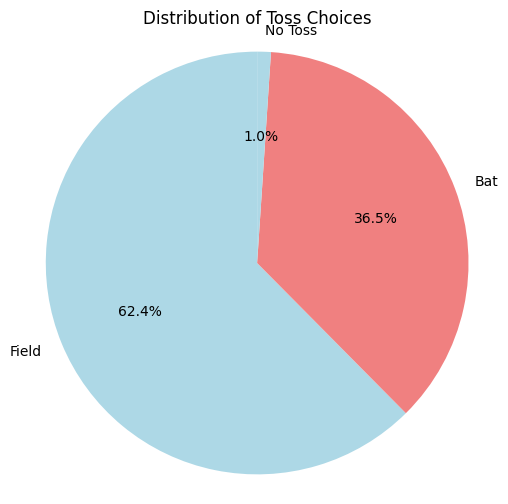

In [51]:
toss_choice_counts = df['toss_choice'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(toss_choice_counts, labels=toss_choice_counts.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightcoral'])
plt.title('Distribution of Toss Choices')
plt.axis('equal')
plt.show()

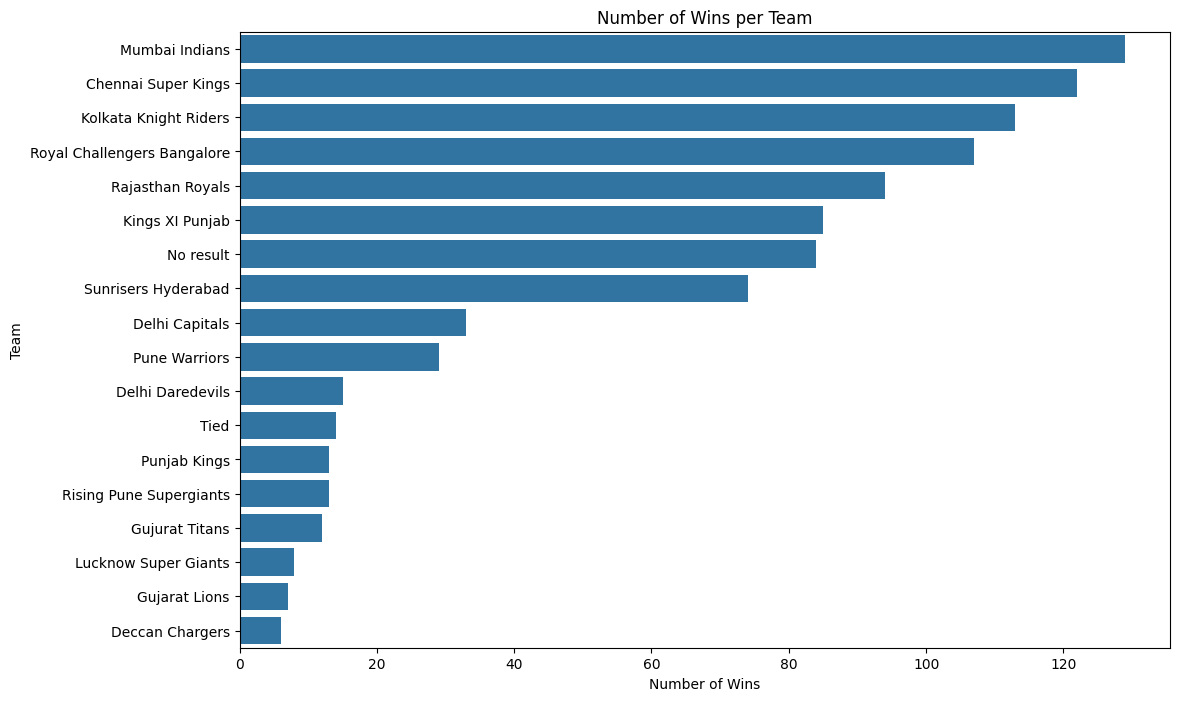

In [56]:
plt.figure(figsize=(12, 8))
sns.countplot(y='winner', data=df, order = df['winner'].value_counts().index)
plt.title('Number of Wins per Team')
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.show()

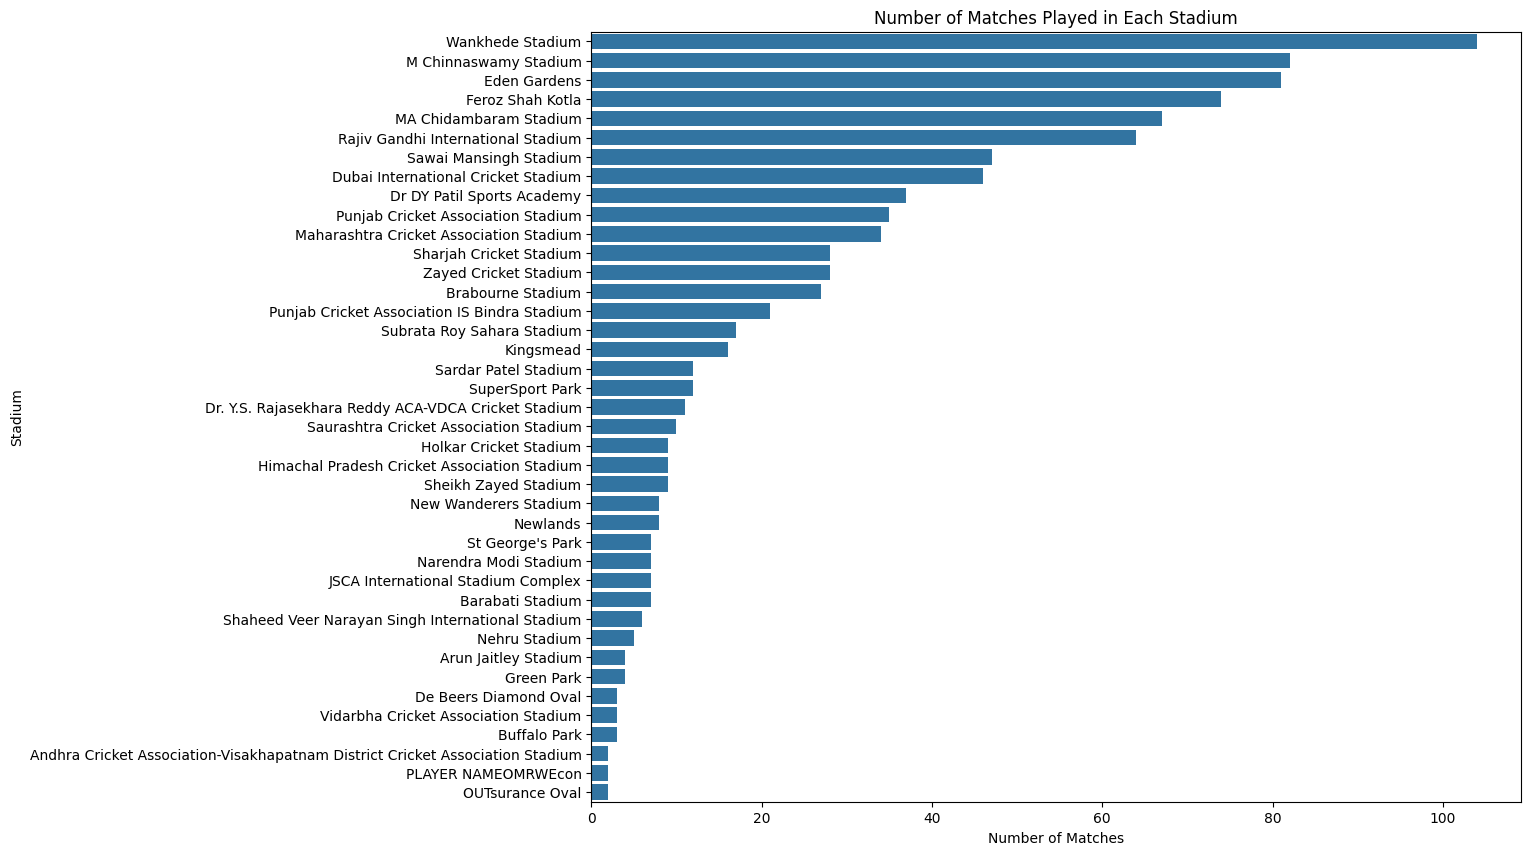

In [53]:
plt.figure(figsize=(12, 10))
sns.countplot(y='stadium', data=df, order = df['stadium'].value_counts().index)
plt.title('Number of Matches Played in Each Stadium')
plt.xlabel('Number of Matches')
plt.ylabel('Stadium')
plt.show()

In [61]:
import plotly.express as px

# Extract the numerical part of the margin and convert it to numeric, handling 'Tied' and 'No result'
df['margin_numeric'] = df['margin'].str.extract(r'(\d+)').astype(float)

fig = px.line(df, x=df.index, y='margin_numeric',
              title='Winning Margin Over Time (by Match Index)',
              labels={'x': 'Match Index', 'margin_numeric': 'Winning Margin (Runs or Wickets)'})

fig.update_layout(hovermode='x unified') # Optional: unify hover across x-axis

fig.show()

In [62]:
# Calculate a rolling average of team1_score to show trend over time
df['team1_score_rolling_avg'] = df['team1_score'].rolling(window=10, min_periods=1).mean()

fig = px.line(df, x=df.index, y='team1_score_rolling_avg',
              title='Rolling Average of Team 1 Score Over Time (by Match Index)',
              labels={'x': 'Match Index', 'team1_score_rolling_avg': 'Rolling Average Team 1 Score'})

fig.update_layout(hovermode='x unified') # Optional: unify hover across x-axis

fig.show()